In [2]:
import torch
import torch
import torch.nn as nn
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Sequential, Module
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

/var/folders/7v/r5yp07196sx_fx1lqtntzf4m0000gn/T/ipykernel_68467/1567782463.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Using device: mps


In [3]:
from get_dataset import GiMeFiveDataset

transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

rafdb_dataset_train = GiMeFiveDataset(
    csv_file="../data/train_labels.csv", img_dir="../data/train/", transform=transform
)
data_train_loader = DataLoader(
    rafdb_dataset_train, batch_size=16, shuffle=True, num_workers=4
)
train_image, train_label = next(iter(data_train_loader))
print(f"Train batch: image shape {train_image.shape}, labels shape {train_label.shape}")

rafdb_dataset_vali = GiMeFiveDataset(
    csv_file="../data/valid_labels.csv", img_dir="../data/valid", transform=transform
)
data_vali_loader = DataLoader(
    rafdb_dataset_vali, batch_size=16, shuffle=False, num_workers=0
)
vali_image, vali_label = next(iter(data_vali_loader))
print(f"Vali batch: image shape {vali_image.shape}, labels shape {vali_label.shape}")

rafdb_dataset_test = GiMeFiveDataset(
    csv_file="../data/test_labels.csv", img_dir="../data/test/", transform=transform
)

data_test_loader = DataLoader(
    rafdb_dataset_test, batch_size=16, shuffle=False, num_workers=0
)

test_image, test_label = next(iter(data_test_loader))
print(f"Test batch: image shape {test_image.shape}, labels shape {test_label.shape}")

Train batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Vali batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Test batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])


In [4]:
class EmotionClassifier(nn.Module):
    def __init__(self):
        super(EmotionClassifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.conv5 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(1024)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(1024, 2048)
        self.fc2 = nn.Linear(2048, 1024) 
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(1024, 6)

    def forward(self, x): # (batch_size, channels=3, 64, 64)
        x = F.relu(self.bn1(self.conv1(x))) # (batch_size, 64, 64, 64)
        x = F.max_pool2d(x, 2) # (batch_size, 64, 32, 32)
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.conv2(x))) # (batch_size, 128, 32, 32)
        x = F.max_pool2d(x, 2) # (batch_size, 128, 16, 16)
        x = self.dropout1(x)
        x = F.relu(self.bn3(self.conv3(x))) # (batch_size, 256, 16, 16)
        x = F.max_pool2d(x, 2) # (batch_size, 256, 8, 8)
        x = self.dropout1(x)
        x = F.relu(self.bn4(self.conv4(x))) # (batch_size, 512, 8, 8)
        x = F.max_pool2d(x, 2) # (batch_size, 512, 4, 4)
        x = self.dropout1(x)
        x = F.relu(self.bn5(self.conv5(x))) # (batch_size, 1024, 4, 4)
        x = F.max_pool2d(x, 2) # (batch_size, 1024, 2, 2)
        # x = self.dropout1(x)
        
        x = self.pool(x) # (batch_size, 1024, 1, 1)
        x = x.view(x.size(0), -1) # (batch_size, 1024) # Flatten
        x = F.relu(self.fc1(x)) # (batch_size, 2048)
        x = self.dropout2(x) # (batch_size, 2048)
        x = F.relu(self.fc2(x)) # (batch_size, 1024)
        x = self.fc3(x) # (batch_size, 6)
        return x

model = EmotionClassifier().to(device)

In [5]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 10478086


In [6]:
def get_class_weights(dataset):
    total_samples = len(dataset)
    label_counter = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
    for _, label in dataset:
        label_counter[label] += 1
    class_weights = [(total_samples / label_counter[i] * 6) for i in range(6)]
    return class_weights

In [7]:
class_weights = torch.Tensor(get_class_weights(rafdb_dataset_train)).to(device)
print("Class weights:", class_weights)

Class weights: tensor([19.2803, 38.3369, 33.1420, 41.3239, 88.6098, 43.3687], device='mps:0')


In [8]:
# Using BCEWithLogitsLoss because we have unbalanced classes
criterion = nn.CrossEntropyLoss(weight=class_weights)
# criterion = nn.BCEWithLogitsLoss(weight=class_weights)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)


patience = 50
best_val_acc = 0
patience_counter = 0

num_epochs = 80
# Needed because of the patience counter and for plotting the learning curve
actual_epochs = 0
model_filename = 'modified_model.pth'

In [9]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    actual_epochs = epoch

    for data in tqdm(data_train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(data_train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for data in data_test_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(data_test_loader)
    test_acc = test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in data_vali_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(data_vali_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}, Validation Loss: {val_loss}, Validation Accuracy: {val_acc}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0 
        torch.save(model.state_dict(), model_filename)
    else:
        patience_counter += 1
        print(f"No improvement in validation accuracy for {patience_counter} epochs.")
    
    if patience_counter > patience:
        print("Stopping early due to lack of improvement in validation accuracy.")
        break

Epoch 1/80: 100%|██████████| 3442/3442 [01:26<00:00, 39.74it/s]


Epoch 1, Train Loss: 1.6830150658207395, Train Accuracy: 0.32844872982150314, Test Loss: 1.42606275041021, Test Accuracy: 0.4455112818050888, Validation Loss: 2.056024924704903, Validation Accuracy: 0.2337228714524207


Epoch 2/80: 100%|██████████| 3442/3442 [01:26<00:00, 40.00it/s]


Epoch 2, Train Loss: 1.413446853027172, Train Accuracy: 0.47131884294819415, Test Loss: 1.1658608713929117, Test Accuracy: 0.5516082573211714, Validation Loss: 1.676910588615819, Validation Accuracy: 0.41569282136894825


Epoch 3/80: 100%|██████████| 3442/3442 [01:25<00:00, 40.03it/s]


...

Epoch 78, Train Loss: 0.3047336436375729, Train Accuracy: 0.8944816691180476, Test Loss: 0.8960182496888166, Test Accuracy: 0.7445991358617379, Validation Loss: 1.5586690020404363, Validation Accuracy: 0.7445742904841403
No improvement in validation accuracy for 33 epochs.


Epoch 79/80: 100%|██████████| 3442/3442 [01:25<00:00, 40.02it/s]


Epoch 79, Train Loss: 0.29846410298414794, Train Accuracy: 0.8951898458353762, Test Loss: 0.9017698245369713, Test Accuracy: 0.7456793086893903, Validation Loss: 1.4474096041368811, Validation Accuracy: 0.7612687813021702
No improvement in validation accuracy for 34 epochs.


Epoch 80/80: 100%|██████████| 3442/3442 [01:26<00:00, 39.89it/s]


Epoch 80, Train Loss: 0.2887940352970928, Train Accuracy: 0.8976775435347097, Test Loss: 0.9267727815404877, Test Accuracy: 0.7262361977916466, Validation Loss: 1.0775482411447324, Validation Accuracy: 0.7796327212020033


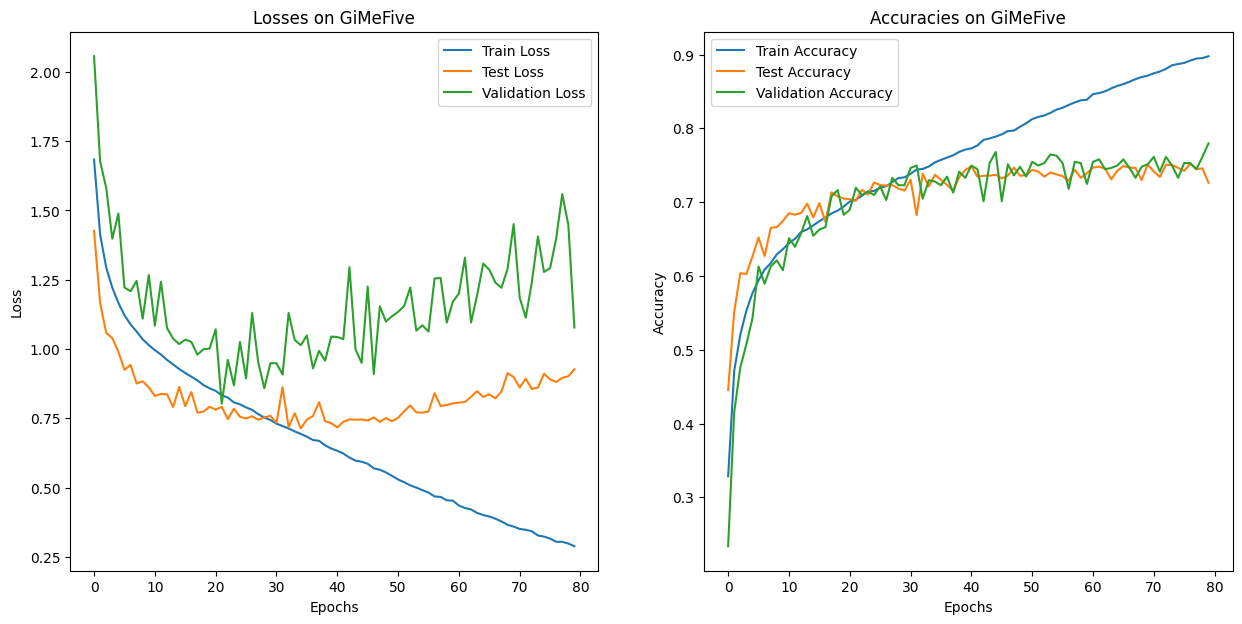

In [14]:
actual_epochs = num_epochs
file_name = "modified_learning_curve.png"

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(
    range(actual_epochs), train_losses, label="Train Loss"
)  # change this number after '(1, _)' to num_epochs+1
plt.plot(
    range(actual_epochs), test_losses, label="Test Loss"
)  # change this number after '(1, _)' to num_epochs+1
plt.plot(
    range(actual_epochs), val_losses, label="Validation Loss"
)  # change this number after '(1, _)' to num_epochs+1
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Losses on GiMeFive")  # change
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    range(actual_epochs), train_accuracies, label="Train Accuracy"
)  # change this number after '(1, _)' to num_epochs+1
plt.plot(
    range(actual_epochs), test_accuracies, label="Test Accuracy"
)  # change this number after '(1, _)' to num_epochs+1
plt.plot(
    range(actual_epochs), val_accuracies, label="Validation Accuracy"
)  # change this number after '(1, _)' to num_epochs+1
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracies on GiMeFive")  # change
plt.legend()

plt.savefig(file_name, dpi=400, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [11]:
df = pd.DataFrame({
    'Epoch': range(1, actual_epochs + 1), # change this number after '(1, _)' to num_epochs+1
    'Train Loss': train_losses,
    'Test Loss': test_losses,
    'Validation Loss': val_losses,
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies,
    'Validation Accuracy': val_accuracies
})
df.to_csv('result_gimefive.csv', index=False) # change this CSV